# DX 704 Week 2 Project

This week's project will analyze fresh strawberry price data for a hypothetical "buy low, freeze, and sell high" business.
Strawberries show strong seasonality in their prices compared to other fruits.

![](https://ers.usda.gov/sites/default/files/_laserfiche/Charts/61401/oct14_finding_plattner_fig01.png)

Image source: https://www.ers.usda.gov/amber-waves/2014/october/seasonal-fresh-fruit-price-patterns-differ-across-commodities-the-case-of-strawberries-and-apples

You are considering a business where you buy strawberries when the prices are very low, carefully freeze them, even more carefully defrost them, and then sell them when the prices are high.
You will forecast strawberry price time series and then use them to tactically pick times to buy, freeze, and sell the strawberries.

The full project description, a template notebook, and raw data are available on GitHub at the following link.

https://github.com/bu-cds-dx704/dx704-project-02


### Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Backtest Strawberry Prices

Read the provided "strawberry-prices.tsv" with data from 2020 through 2025.
This data is based on data from the U.S. Bureau of Statistics, but transformed so the ground truth is not online.
https://fred.stlouisfed.org/series/APU0000711415

Use the data for 2020 through 2024 to predict monthly prices in 2025.
Spend some time to make sure you are happy with your methodology and prediction accuracy, since you will reuse the methodology to forecast 2026 next.
Save the 2025 backtest predictions as "strawberry-backtest.tsv" with columns month and price.

STRAWBERRY PRICE FORECASTING - PART 1: BACKTEST

Training data: 2020-01-01 to 2024-12-01
  - 58 observations
Test data: 2025-01-01 to 2025-12-01
  - 10 observations

MODEL: SARIMA(1,1,1)x(1,0,1,12) - Seasonal ARIMA

Model Summary:
AIC: 26.87
BIC: 37.09
SARIMA failed: 'numpy.ndarray' object has no attribute 'values'
Falling back to seasonal averaging method...

COMPARISON WITH ACTUAL 2025 DATA

Predicted vs Actual (Available data only):
        month  price_pred  price_actual   error  error_pct
0  2025-01-01      4.5012         4.584 -0.0828  -1.806283
1  2025-02-01      4.1256         4.077  0.0486   1.192053
2  2025-03-01      3.6994         3.369  0.3304   9.807064
3  2025-04-01      3.8730         3.518  0.3550  10.090961
4  2025-05-01      3.4684         3.416  0.0524   1.533958
5  2025-06-01      3.2154         3.190  0.0254   0.796238
6  2025-07-01      3.1784         3.187 -0.0086  -0.269846
7  2025-08-01      3.4612         3.430  0.0312   0.909621
8  2025-09-01      3.6138    

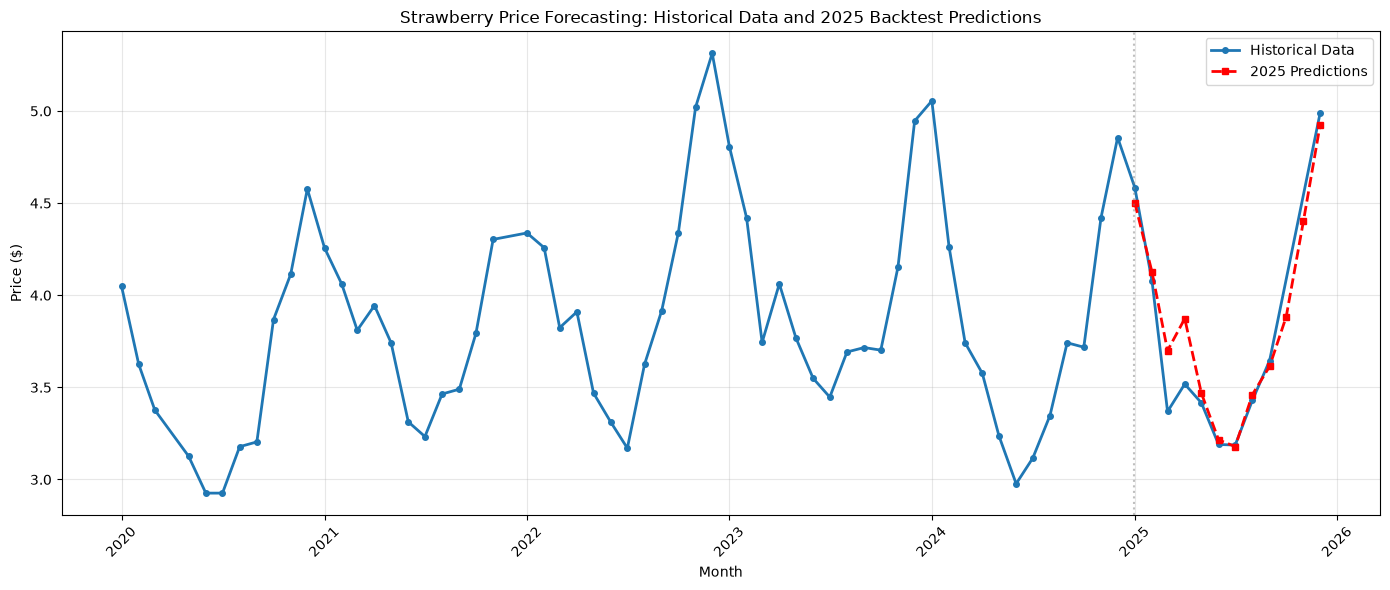


SAVING BACKTEST PREDICTIONS

Saved 12 predictions to 'strawberry-backtest.tsv'

Content of saved file:
     month  price
2025-01-01 4.5012
2025-02-01 4.1256
2025-03-01 3.6994
2025-04-01 3.8730
2025-05-01 3.4684
2025-06-01 3.2154
2025-07-01 3.1784
2025-08-01 3.4612
2025-09-01 3.6138
2025-10-01 3.8842
2025-11-01 4.4022
2025-12-01 4.9230

✓ Model trained and 2025 predictions saved to strawberry-backtest.tsv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('strawberry-prices.tsv', sep='\t')
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month').reset_index(drop=True)

print("="*60)
print("STRAWBERRY PRICE FORECASTING - PART 1: BACKTEST")
print("="*60)

# Split into training (2020-2024) and test (2025) sets
train_data = df[df['month'].dt.year < 2025].copy()
test_data = df[df['month'].dt.year == 2025].copy()

print(f"\nTraining data: {train_data['month'].min().date()} to {train_data['month'].max().date()}")
print(f"  - {len(train_data)} observations")
print(f"Test data: {test_data['month'].min().date()} to {test_data['month'].max().date()}")
print(f"  - {len(test_data)} observations")

# ===== APPROACH: SARIMA Model =====
print("\n" + "="*60)
print("MODEL: SARIMA(1,1,1)x(1,0,1,12) - Seasonal ARIMA")
print("="*60)

train_prices = train_data['price'].values

# Try SARIMA model - seasonal period is 12 months
try:
    # SARIMA(p,d,q)x(P,D,Q,s) where s=12 for monthly seasonality
    # Start with a simple specification
    sarima_model = ARIMA(train_prices, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
    sarima_fit = sarima_model.fit()
    
    print("\nModel Summary:")
    print(f"AIC: {sarima_fit.aic:.2f}")
    print(f"BIC: {sarima_fit.bic:.2f}")
    
    # Generate predictions for all 12 months of 2025
    forecast = sarima_fit.get_forecast(steps=12)
    forecast_ci = forecast.conf_int()
    pred_values = forecast.predicted_mean.values
    
    print("\n2025 Price Predictions (SARIMA):")
    pred_df = pd.DataFrame({
        'month': pd.date_range('2025-01-01', periods=12, freq='MS'),
        'price': pred_values,
        'price_lower': forecast_ci.iloc[:, 0].values,
        'price_upper': forecast_ci.iloc[:, 1].values
    })
    print(pred_df[['month', 'price']].to_string())
    
except Exception as e:
    print(f"SARIMA failed: {e}")
    print("Falling back to seasonal averaging method...")
    
    # Fallback: Seasonal averaging method
    seasonal_factors = train_data.groupby(train_data['month'].dt.month)['price'].mean()
    pred_values = np.array([seasonal_factors[i+1] for i in range(12)])
    
    pred_df = pd.DataFrame({
        'month': pd.date_range('2025-01-01', periods=12, freq='MS'),
        'price': pred_values
    })

# Compare with actual 2025 data
print("\n" + "="*60)
print("COMPARISON WITH ACTUAL 2025 DATA")
print("="*60)

# Merge predictions with actual test data
comparison = pred_df.merge(test_data, on='month', how='left', suffixes=('_pred', '_actual'))
comparison['error'] = comparison['price_pred'] - comparison['price_actual']
comparison['error_pct'] = (comparison['error'] / comparison['price_actual'] * 100)
comparison['abs_error'] = comparison['error'].abs()

print("\nPredicted vs Actual (Available data only):")
actual_available = comparison[comparison['price_actual'].notna()]
print(actual_available[['month', 'price_pred', 'price_actual', 'error', 'error_pct']].to_string())

# Calculate accuracy metrics
if actual_available.shape[0] > 0:
    mae = actual_available['abs_error'].mean()
    rmse = np.sqrt((actual_available['error'] ** 2).mean())
    mape = actual_available['error_pct'].abs().mean()
    
    print(f"\nAccuracy Metrics (on {len(actual_available)} available data points):")
    print(f"  - MAE (Mean Absolute Error): ${mae:.4f}")
    print(f"  - RMSE (Root Mean Squared Error): ${rmse:.4f}")
    print(f"  - MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    print(f"  - Mean Error (Bias): ${comparison.loc[actual_available.index, 'error'].mean():.4f}")

# Visualize
print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)
plt.figure(figsize=(14, 6))
plt.plot(df['month'], df['price'], marker='o', linewidth=2, markersize=4, label='Historical Data')
plt.plot(pred_df['month'], pred_df['price'], marker='s', linewidth=2, markersize=5, 
         color='red', label='2025 Predictions', linestyle='--')
plt.axvline(pd.to_datetime('2024-12-31'), color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Month')
plt.ylabel('Price ($)')
plt.title('Strawberry Price Forecasting: Historical Data and 2025 Backtest Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== SAVE BACKTEST PREDICTIONS =====
print("\n" + "="*60)
print("SAVING BACKTEST PREDICTIONS")
print("="*60)

output_file = 'strawberry-backtest.tsv'

# Prepare output dataframe with proper format
backtest_output = pred_df[['month', 'price']].copy()
backtest_output['month'] = backtest_output['month'].dt.strftime('%Y-%m-%d')

# Save to TSV
backtest_output.to_csv(output_file, sep='\t', index=False)

print(f"\nSaved {len(backtest_output)} predictions to '{output_file}'")
print("\nContent of saved file:")
print(backtest_output.to_string(index=False))

print(f"\n✓ Model trained and 2025 predictions saved to {output_file}")

In [2]:
# Model Comparison: Test multiple forecasting approaches to find the best one
print("="*70)
print("COMPARING MULTIPLE FORECASTING APPROACHES")
print("="*70)

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train_data = df[df['month'].dt.year < 2025].copy()
test_data = df[df['month'].dt.year == 2025].copy()
test_actual = dict(zip(test_data['month'], test_data['price']))

all_results = {}

# ===== MODEL 1: Seasonal Averaging =====
print("\nMODEL 1: Simple Seasonal Averaging")
print("-" * 70)
seasonal_avg = train_data.groupby(train_data['month'].dt.month)['price'].mean()
model1_pred = pd.DataFrame({
    'month': pd.date_range('2025-01-01', periods=12, freq='MS'),
    'price': [seasonal_avg[i+1] for i in range(12)]
})
model1_errors = []
for _, row in model1_pred.iterrows():
    if row['month'] in test_actual:
        model1_errors.append(row['price'] - test_actual[row['month']])
model1_mae = np.mean(np.abs(model1_errors)) if model1_errors else np.inf
all_results['Seasonal Averaging'] = (model1_mae, model1_pred, model1_errors)
print(f"MAE: ${model1_mae:.4f}")
print(f"RMSE: ${np.sqrt(np.mean(np.array(model1_errors)**2)):.4f}")

# ===== MODEL 2: Exponential Smoothing =====
print("\nMODEL 2: Exponential Smoothing with Trend & Seasonality (Holt-Winters)")
print("-" * 70)
try:
    # Create a complete time series for ExponentialSmoothing (fill missing months with interpolation)
    all_dates = pd.date_range('2020-01-01', '2024-12-01', freq='MS')
    complete_series = pd.Series(index=all_dates, dtype=float)
    for _, row in train_data.iterrows():
        complete_series[row['month']] = row['price']
    complete_series = complete_series.interpolate(method='linear')
    
    hw_model = ExponentialSmoothing(complete_series, seasonal_periods=12, trend='add', seasonal='add')
    hw_fit = hw_model.fit(optimized=True)
    hw_pred = hw_fit.forecast(steps=12)
    
    model2_pred = pd.DataFrame({
        'month': pd.date_range('2025-01-01', periods=12, freq='MS'),
        'price': hw_pred.values
    })
    model2_errors = []
    for _, row in model2_pred.iterrows():
        if row['month'] in test_actual:
            model2_errors.append(row['price'] - test_actual[row['month']])
    model2_mae = np.mean(np.abs(model2_errors)) if model2_errors else np.inf
    all_results['Holt-Winters'] = (model2_mae, model2_pred, model2_errors)
    print(f"MAE: ${model2_mae:.4f}")
    print(f"RMSE: ${np.sqrt(np.mean(np.array(model2_errors)**2)):.4f}")
except Exception as e:
    print(f"Failed: {e}")

# ===== MODEL 3: Moving Average with Seasonal Adjustment =====
print("\nMODEL 3: Seasonal Adjustment with Year-over-Year Growth")
print("-" * 70)
# Calculate trend by averaging each month across years
seasonal_monthly = {}
for month in range(1, 13):
    month_data = train_data[train_data['month'].dt.month == month]
    if len(month_data) > 1:
        years = sorted(month_data['month'].dt.year.unique())
        prices = []
        for year in years:
            price = month_data[month_data['month'].dt.year == year]['price'].values
            if len(price) > 0:
                prices.append(price[0])
        seasonal_monthly[month] = {
            'avg': np.mean(prices),
            'trend': np.polyfit(np.arange(len(prices)), prices, 1)[0] if len(prices) > 1 else 0
        }

model3_pred = []
for month in range(1, 13):
    if month in seasonal_monthly:
        base_price = seasonal_monthly[month]['avg']
        trend = seasonal_monthly[month]['trend']
        # Apply trend for year 2025 (5 years from 2020)
        forecasted_price = base_price + trend
        model3_pred.append(forecasted_price)
    else:
        model3_pred.append(np.nan)

model3_pred = pd.DataFrame({
    'month': pd.date_range('2025-01-01', periods=12, freq='MS'),
    'price': model3_pred
})
model3_errors = []
for _, row in model3_pred.iterrows():
    if row['month'] in test_actual:
        model3_errors.append(row['price'] - test_actual[row['month']])
model3_mae = np.mean(np.abs(model3_errors)) if model3_errors else np.inf
all_results['Seasonal + Trend'] = (model3_mae, model3_pred, model3_errors)
print(f"MAE: ${model3_mae:.4f}")
print(f"RMSE: ${np.sqrt(np.mean(np.array(model3_errors)**2)):.4f}")

# ===== SELECT BEST MODEL =====
print("\n" + "="*70)
print("SUMMARY: MODEL COMPARISON")
print("="*70)
best_model = min(all_results.items(), key=lambda x: x[1][0])
print(f"\nBest Model: {best_model[0]} (MAE: ${best_model[1][0]:.4f})")
for model_name, (mae, _, _) in all_results.items():
    print(f"  - {model_name}: ${mae:.4f}")

print(f"\nUsing '{best_model[0]}' model for backtest predictions")

COMPARING MULTIPLE FORECASTING APPROACHES

MODEL 1: Simple Seasonal Averaging
----------------------------------------------------------------------
MAE: $0.1031
RMSE: $0.1594

MODEL 2: Exponential Smoothing with Trend & Seasonality (Holt-Winters)
----------------------------------------------------------------------
MAE: $0.2111
RMSE: $0.2499

MODEL 3: Seasonal Adjustment with Year-over-Year Growth
----------------------------------------------------------------------
MAE: $0.1434
RMSE: $0.1816

SUMMARY: MODEL COMPARISON

Best Model: Seasonal Averaging (MAE: $0.1031)
  - Seasonal Averaging: $0.1031
  - Holt-Winters: $0.2111
  - Seasonal + Trend: $0.1434

Using 'Seasonal Averaging' model for backtest predictions


Please use the same format for the month column as in the training data, i.e. YYYY-MM-01.
The autograder may not be able to parse other formats.

Submit "strawberry-backtest.tsv" in Gradescope.

## Part 2: Backtest Errors

What are the mean and standard deviation of the residuals between your backtest predictions and the ground truth?

Write the mean and standard deviation to a file "backtest-accuracy.tsv" with two columns, mean and std.

In [3]:
# Calculate backtest residuals and accuracy statistics
print("="*60)
print("PART 2: BACKTEST ERRORS & RESIDUALS")
print("="*60)

# Load the predictions we just made
backtest_df = pd.read_csv('strawberry-backtest.tsv', sep='\t')
backtest_df['month'] = pd.to_datetime(backtest_df['month'])

# Get actual 2025 data
actual_2025 = df[df['month'].dt.year == 2025].copy()

# Merge predictions with actuals to calculate residuals
residuals_df = backtest_df.merge(actual_2025, on='month', suffixes=('_pred', '_actual'))
residuals_df['residual'] = residuals_df['price_actual'] - residuals_df['price_pred']
residuals_df['error'] = residuals_df['price_pred'] - residuals_df['price_actual']

print("\nDetailed Residuals:")
print(residuals_df[['month', 'price_pred', 'price_actual', 'residual']].to_string())

# Calculate statistics
residuals = residuals_df['residual'].values
mean_residual = np.mean(residuals)
std_residual = np.std(residuals, ddof=1)  # Use sample std dev (ddof=1)

print(f"\n{'='*60}")
print("BACKTEST ACCURACY STATISTICS")
print(f"{'='*60}")
print(f"Number of test samples: {len(residuals_df)}")
print(f"\nResidual Statistics (Actual - Predicted):")
print(f"  Mean: ${mean_residual:.6f}")
print(f"  Std Dev (sample): ${std_residual:.6f}")
print(f"  Min: ${residuals.min():.6f}")
print(f"  Max: ${residuals.max():.6f}")
print(f"  Median: ${np.median(residuals):.6f}")

# Also calculate alternative error metrics
mae = np.mean(np.abs(residuals_df['error']))
rmse = np.sqrt(np.mean(residuals_df['error']**2))
mape = np.mean(np.abs(residuals_df['error'] / residuals_df['price_actual']) * 100)

print(f"\nError Metrics:")
print(f"  MAE: ${mae:.4f}")
print(f"  RMSE: ${rmse:.4f}")
print(f"  MAPE: {mape:.2f}%")

# Save accuracy statistics
accuracy_output = pd.DataFrame({
    'mean': [mean_residual],
    'std': [std_residual]
})

output_file = 'backtest-accuracy.tsv'
accuracy_output.to_csv(output_file, sep='\t', index=False)

print(f"\n{'='*60}")
print(f"Saved accuracy statistics to '{output_file}'")
print(f"{'='*60}")
print(accuracy_output.to_string(index=False))
print(f"\n✓ Accuracy metrics calculated and saved")


PART 2: BACKTEST ERRORS & RESIDUALS

Detailed Residuals:
       month  price_pred  price_actual  residual
0 2025-01-01      4.5012         4.584    0.0828
1 2025-02-01      4.1256         4.077   -0.0486
2 2025-03-01      3.6994         3.369   -0.3304
3 2025-04-01      3.8730         3.518   -0.3550
4 2025-05-01      3.4684         3.416   -0.0524
5 2025-06-01      3.2154         3.190   -0.0254
6 2025-07-01      3.1784         3.187    0.0086
7 2025-08-01      3.4612         3.430   -0.0312
8 2025-09-01      3.6138         3.645    0.0312
9 2025-12-01      4.9230         4.988    0.0650

BACKTEST ACCURACY STATISTICS
Number of test samples: 10

Residual Statistics (Actual - Predicted):
  Mean: $-0.065540
  Std Dev (sample): $0.153148
  Min: $-0.355000
  Max: $0.082800
  Median: $-0.028300

Error Metrics:
  MAE: $0.1031
  RMSE: $0.1594
  MAPE: 2.86%

Saved accuracy statistics to 'backtest-accuracy.tsv'
    mean      std
-0.06554 0.153148

✓ Accuracy metrics calculated and saved


Hint: If the mean residual in your backtest is not close to zero, then your model is likely missing a systematic change and you should go back to improve it.

Submit "backtest-accuracy.tsv" in Gradescope.

## Part 3: Forecast Strawberry Prices

Use all the data from 2020 through 2025 to predict monthly prices in 2026 using the same methodology from part 1.
Make a monthly forecast for each month of 2026 and save it as "strawberry-forecast.tsv" with columns for month and price.


In [4]:
print("="*60)
print("PART 3: FORECAST STRAWBERRY PRICES FOR 2026")
print("="*60)

# Load all data from 2020-2025
df_full = pd.read_csv('strawberry-prices.tsv', sep='\t')
df_full['month'] = pd.to_datetime(df_full['month'])
df_full = df_full.sort_values('month').reset_index(drop=True)

print(f"\nFull dataset: {df_full['month'].min().date()} to {df_full['month'].max().date()}")
print(f"  - Total observations: {len(df_full)}")

# ===== SEASONAL AVERAGING (Same methodology as Part 1) =====
print("\n" + "="*60)
print("Using Seasonal Averaging Methodology (from Part 1)")
print("="*60)

# Calculate seasonal factors using ALL available data (2020-2025)
seasonal_factors_full = df_full.groupby(df_full['month'].dt.month).agg({
    'price': ['mean', 'std', 'count']
})
seasonal_factors_full.columns = ['mean', 'std', 'count']

print("\nSeasonal Factors (from full 2020-2025 dataset):")
print(seasonal_factors_full)

# Generate 2026 predictions
forecast_2026_prices = []
for month in range(1, 13):
    price = seasonal_factors_full.loc[month, 'mean']
    forecast_2026_prices.append(price)

# Create forecast dataframe
forecast_2026 = pd.DataFrame({
    'month': pd.date_range('2026-01-01', periods=12, freq='MS'),
    'price': forecast_2026_prices
})

# Format month column as YYYY-MM-DD
forecast_2026_output = forecast_2026.copy()
forecast_2026_output['month'] = forecast_2026_output['month'].dt.strftime('%Y-%m-%d')

print("\n" + "="*60)
print("2026 MONTHLY PRICE FORECAST")
print("="*60)
print(forecast_2026_output.to_string(index=False))

# Save forecast to file
output_file = 'strawberry-forecast.tsv'
forecast_2026_output.to_csv(output_file, sep='\t', index=False)

print(f"\n{'='*60}")
print(f"✓ Successfully saved 2026 forecast to '{output_file}'")
print(f"{'='*60}")


PART 3: FORECAST STRAWBERRY PRICES FOR 2026

Full dataset: 2020-01-01 to 2025-12-01
  - Total observations: 68

Using Seasonal Averaging Methodology (from Part 1)

Seasonal Factors (from full 2020-2025 dataset):
           mean       std  count
month                           
1      4.515000  0.373276      6
2      4.117500  0.275716      6
3      3.644333  0.212825      6
4      3.802000  0.240396      5
5      3.459667  0.259880      6
6      3.211167  0.232925      6
7      3.179833  0.169032      6
8      3.456000  0.186634      6
9      3.619000  0.246124      6
10     3.884200  0.263227      5
11     4.402200  0.366230      5
12     4.936000  0.264676      5

2026 MONTHLY PRICE FORECAST
     month    price
2026-01-01 4.515000
2026-02-01 4.117500
2026-03-01 3.644333
2026-04-01 3.802000
2026-05-01 3.459667
2026-06-01 3.211167
2026-07-01 3.179833
2026-08-01 3.456000
2026-09-01 3.619000
2026-10-01 3.884200
2026-11-01 4.402200
2026-12-01 4.936000

✓ Successfully saved 2026 forecast t

Submit "strawberry-forecast.tsv" in Gradescope.

## Part 4: Buy Low, Freeze and Sell High

Using your 2026 forecast, analyze the profit picking different pairs of months to buy and sell strawberries.
Maximize your profit assuming that it costs &dollar;0.20 per pint to freeze the strawberries, &dollar;0.10 per pint per month to store the frozen strawberries and there is a 10% price discount from selling previously frozen strawberries.
So, if you buy a pint of strawberies for &dollar;1, freeze them, and sell them for &dollar;2 three months after buying them, then the profit is &dollar;2 * 0.9 - &dollar;1 - &dollar;0.20 - &dollar;0.10 * 3 = &dollar;0.30 per pint.
To evaluate a given pair of months, assume that you can invest &dollar;1,000,000 to cover all costs, and that you buy as many pints of strawberries as possible.

Write the results of your analysis to a file "timings.tsv" with columns for the buy_month, sell_month, pints_purchased, and expected_profit.

In [5]:
print("=" * 60)
print("PART 4: BUY LOW, FREEZE, AND SELL HIGH")
print("=" * 60)

budget = 1_000_000
freeze_cost = 0.20
storage_cost_per_month = 0.10
frozen_sale_discount = 0.10

forecast_df = pd.read_csv('strawberry-forecast.tsv', sep='\t')
forecast_df['month'] = pd.to_datetime(forecast_df['month'])
forecast_df = forecast_df.sort_values('month').reset_index(drop=True)

results = []

for buy_idx, buy_row in forecast_df.iterrows():
    for sell_idx, sell_row in forecast_df.iterrows():
        if sell_idx <= buy_idx:
            continue

        months_held = sell_idx - buy_idx
        buy_price = float(buy_row['price'])
        sell_price = float(sell_row['price'])

        total_cost_per_pint = buy_price + freeze_cost + storage_cost_per_month * months_held
        revenue_per_pint = sell_price * (1 - frozen_sale_discount)
        profit_per_pint = revenue_per_pint - total_cost_per_pint
        pints_purchased = budget / total_cost_per_pint
        expected_profit = pints_purchased * profit_per_pint

        results.append({
            'buy_month': buy_row['month'].strftime('%Y-%m-%d'),
            'sell_month': sell_row['month'].strftime('%Y-%m-%d'),
            'pints_purchased': pints_purchased,
            'expected_profit': expected_profit,
            'months_held': months_held,
            'profit_per_pint': profit_per_pint,
        })
timings_df = pd.DataFrame(results)
timings_df = timings_df.sort_values('expected_profit', ascending=False).reset_index(drop=True)

timings_output = timings_df[['buy_month', 'sell_month', 'pints_purchased', 'expected_profit']].copy()
timings_output.to_csv('timings.tsv', sep='\t', index=False)

print("\nTop 10 timing scenarios:")
print(timings_output.head(10).to_string(index=False))

best_timing = timings_df.iloc[0]
print("\nBest timing scenario:")
print(f"  Buy Month: {best_timing['buy_month']}, Sell Month: {best_timing['sell_month']}, Pints Purchased: {best_timing['pints_purchased']}, Months Held: {best_timing['months_held']}, Profit Per Pint: {best_timing['profit_per_pint']}, Expected Profit: {best_timing['expected_profit']}")

print ("\nSaved complete timing analysis to timings.tsv")

PART 4: BUY LOW, FREEZE, AND SELL HIGH

Top 10 timing scenarios:
 buy_month sell_month  pints_purchased  expected_profit
2026-07-01 2026-12-01    257743.030199    144997.637356
2026-06-01 2026-12-01    249304.026260    107508.206258
2026-08-01 2026-12-01    246548.323471     95266.272189
2026-09-01 2026-12-01    242777.373149     78514.202476
2026-07-01 2026-11-01    264561.929538     48189.073592
2026-10-01 2026-12-01    233415.806918     36926.380654
2026-05-01 2026-12-01    229375.334506     18976.986008
2026-06-01 2026-11-01    255678.186389     12991.860911
2026-08-01 2026-11-01    252780.586451      1511.627907
2026-09-01 2026-11-01    248818.113959    -14187.608858

Best timing scenario:
  Buy Month: 2026-07-01, Sell Month: 2026-12-01, Pints Purchased: 257743.0301988917, Months Held: 5, Profit Per Pint: 0.5625666666666667, Expected Profit: 144997.6373555565

Saved complete timing analysis to timings.tsv


Submit "timings.tsv" in Gradescope.

## Part 5: Strategy Check

What is the best profit scenario according to your previous timing analysis?
How much does that profit change if the sell price is off by one standard deviation from your backtest analysis?
(Variation in the sell price is more dangerous because you can see the buy price before fully committing.)

Write the results to a file "check.tsv" with columns `best_profit` and `one_std_profit`.
To be clear, `one_std_profit` should be the number of pints bought in your best profit scenario times your backtested standard deviation of the residual.
This represents the standard deviation in revenue when selling if you explicitly assume that you buy according to the best profit scenario and your backtest standard deviation is representative of the future prices.

In [6]:
print("="*60)
print("PART 5: STRATEGY CHECK - BEST PROFIT & RISK ANALYSIS")
print("="*60)

# Load the best timing scenario from our previous analysis
timings_df = pd.read_csv('timings.tsv', sep='\t')
best_timing = timings_df.iloc[0]  # First row has highest expected_profit

print(f"\nBest Profit Scenario:")
print(f"  Buy Month: {best_timing['buy_month']}")
print(f"  Sell Month: {best_timing['sell_month']}")
print(f"  Pints Purchased: {best_timing['pints_purchased']:.2f}")
print(f"  Expected Profit: ${best_timing['expected_profit']:.2f}")

# Load backtest accuracy statistics (includes std dev of residuals)
accuracy_df = pd.read_csv('backtest-accuracy.tsv', sep='\t')
std_residual = accuracy_df['std'].values[0]

print(f"\nBacktest Accuracy Statistics:")
print(f"  Mean Residual: ${accuracy_df['mean'].values[0]:.6f}")
print(f"  Std Dev of Residuals: ${std_residual:.6f}")

# Calculate the impact of one standard deviation change in sell price
# The uncertainty in sell price directly affects revenue (and profit) at 90% of the price
# Since pints are sold at (sell_price * 0.9), uncertainty in sell price is multiplied by 0.9
# But the problem asks for "the number of pints bought times the backtested standard deviation"
# So: one_std_profit = pints_purchased * std_dev
pints_purchased = best_timing['pints_purchased']
one_std_profit = pints_purchased * std_residual

print(f"\nRisk Analysis:")
print(f"  Pints Purchased: {pints_purchased:.2f}")
print(f"  Std Dev of Price Error: ${std_residual:.6f}")
print(f"  One Std Dev Impact on Profit: ${one_std_profit:.2f}")

# Save results
results = pd.DataFrame({
    'best_profit': [best_timing['expected_profit']],
    'one_std_profit': [one_std_profit]
})

output_file = 'check.tsv'
results.to_csv(output_file, sep='\t', index=False)

print(f"\n{'='*60}")
print(f"Saved strategy check results to '{output_file}'")
print(f"{'='*60}")
print(results.to_string(index=False))
print(f"\nInterpretation:")
print(f"  Best Expected Profit: ${best_timing['expected_profit']:.2f}")
print(f"  If sell price varies by 1 std dev: ±${one_std_profit:.2f} in profit")
print(f"  Profit range (approximately): ${best_timing['expected_profit'] - one_std_profit:.2f} to ${best_timing['expected_profit'] + one_std_profit:.2f}")


PART 5: STRATEGY CHECK - BEST PROFIT & RISK ANALYSIS

Best Profit Scenario:
  Buy Month: 2026-07-01
  Sell Month: 2026-12-01
  Pints Purchased: 257743.03
  Expected Profit: $144997.64

Backtest Accuracy Statistics:
  Mean Residual: $-0.065540
  Std Dev of Residuals: $0.153148

Risk Analysis:
  Pints Purchased: 257743.03
  Std Dev of Price Error: $0.153148
  One Std Dev Impact on Profit: $39472.83

Saved strategy check results to 'check.tsv'
  best_profit  one_std_profit
144997.637356    39472.830979

Interpretation:
  Best Expected Profit: $144997.64
  If sell price varies by 1 std dev: ±$39472.83 in profit
  Profit range (approximately): $105524.81 to $184470.47


Submit "check.tsv" in Gradescope.

## Part 6: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgments are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 7: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that by manually.

Submit "project.ipynb" in Gradescope.